# Media Source Extraction Pipeline
 
```
Setup & data load
  → Step 1:  Split cells into individual source candidates
  → Step 2:  Clean each string
  → Step 3:  Frequency table + distribution chart
  → Step 3a: Visualise distribution (how many sources vs how many mentions) 
  → Step 4:  Extract frequent words (≥4 mentions) from long sentences → new freq table + chart 
  → Step 5: Social-media column audit — what did people write in Facebook/Instagram/etc? 
  → Step 6:  Unification
```

# Setup and data load

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from openpyxl.styles import Alignment
from openpyxl.utils import get_column_letter

df = pd.read_csv('media_sources_internship.csv')
print(df.shape)
print(list(df.columns))

(928, 21)
['PROLIFIC_PID', 'Facebook', 'Facebook_freq', 'Instagram', 'Instagram_freq', 'TV news programs', 'TV news programs_freq', 'TikTok', 'TikTok_freq', 'Twitter/X', 'Twitter/X_freq', 'YouTube', 'YouTube_freq', 'online news sites', 'online news sites_freq', 'podcasts', 'podcasts_freq', 'printed newspapers', 'printed newspapers_freq', 'the radio', 'the radio_freq']


In [2]:
# Survey columns where the platform itself is social media
SM_SURVEY_COLS = ['Facebook', 'Instagram', 'TikTok', 'Twitter/X', 'YouTube']

# Survey columns for traditional media
MM_SURVEY_COLS = ['TV news programs', 'online news sites', 'podcasts',
                  'printed newspapers', 'the radio']

# All free-text columns (drop ID and pre-aggregated freq columns)
source_cols = [c for c in df.columns
               if not c.endswith('_freq') and c != 'PROLIFIC_PID']

# Stack into one long Series, keep track of which column each entry came from
all_text_with_col = (
    df[source_cols]
    .stack()
    .reset_index()
    .rename(columns={'level_1': 'survey_col', 0: 'text'})
    .assign(text=lambda d: d['text'].astype(str))
)
all_text = all_text_with_col['text']
print(f"Total cells: {len(all_text)}")

Total cells: 2771


# Step 1: Split cells into individual source candidates

Cells contain multiple sources separated by commas, semicolons, newlines, or 'and'.
'and' is tricky — only split on it when the text to the left is ≤30 chars (likely a short name, not a sentence).
Sources whose names contain 'and' go in PROTECTED_NAMES — never split those.

In [3]:
PROTECTED_NAMES = {
    'aba and preach',
    'faith and freedom coalition', 
    'law and crime',
    'crime and justice',
    'meet the press',
    'msnbc',  # kept separate — 'meet the press' is a program, 'msnbc' is a channel
    'breaking points with krystal and saagar',
    'Fox & Friends',
    'Fox and Friends'
} 


def split_sources(text):
    segs = re.split(r'[;,\n:/]|\.\.\.+', text)
    result = []
    for seg in segs:
        if seg.strip().lower() in PROTECTED_NAMES:
            result.append(seg)
            continue
        parts = re.split(r'\s+and\s+', seg, flags=re.IGNORECASE)
        result.extend(parts)
    return [s.strip() for s in result if s.strip()]

# Step 2: Clean each candidate string

Lowercase, strip URLs, remove domain endings, remove noise punctuation.
Also record which survey column the entry came from — needed later for MM-in-SM detection.

In [4]:
def clean(s):
    s = s.lower()
    s = re.sub(r'https?://|www\.|//', '', s)
    # .co.uk before .co so we catch the full thing
    s = re.sub(r'\.co\.uk|\.com|\.org|\.net|\.co|\.uk|\.gov|\.edu', '', s)
    s = s.replace('_', ' ')
    s = re.sub(r'[@™\'\"()\[\]]', '', s)
    s = s.encode('ascii', 'ignore').decode('ascii')
    s = s.strip(' /-.')
    return s

 

In [5]:
# Explode: one row per split+cleaned piece, keeping survey_col
rows = []
for _, row in all_text_with_col.iterrows():
    for piece in split_sources(row['text']):
        c = clean(piece)
        if c:
            rows.append({
                'cleaned':    c,
                'survey_col': row['survey_col'],
                'col_type':   'SM_col' if row['survey_col'] in SM_SURVEY_COLS else 'MM_col',
            })

exploded = pd.DataFrame(rows)
all_cleaned = exploded['cleaned']

print(len(all_cleaned))
print(all_cleaned.nunique())
all_cleaned

6372
2522


0                                              music
1                               film news from bands
2                                              movie
3       show pages that i follow like the black keys
4                                          meshuggah
                            ...                     
6367                                  new york times
6368                                 washington post
6369                                        ncb news
6370                                     google news
6371                                      espn radio
Name: cleaned, Length: 6372, dtype: object

# Step 3: Frequency table

Count how often each unique string appears, foocusing on strings mentioned >3 times  

In [6]:
freq = all_cleaned.value_counts().reset_index()
freq.columns = ['source', 'count'] 
top = freq[freq['count'] > 3 ].copy() 
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top.to_string())

                      source  count
0                        cnn    623
1                   fox news    188
2                      msnbc    184
3                        npr    157
4             new york times    139
5                        bbc    130
6                        nbc    114
7                        abc    106
8                        fox     89
9            washington post     89
10                       cbs     81
11                   reuters     64
12                  abc news     52
13               google news     45
14                      cnbc     44
15       wall street journal     44
16                  ny times     44
17        the new york times     44
18                local news     38
19                 usa today     36
20                  bbc news     36
21                       nyt     34
22                  nbc news     34
23                        ap     32
24              the guardian     29
25                     yahoo     29
26          nbc nightly news

# Step 3a: Distribution chart

X axis = number of mentions (count).
Y axis = how many unique strings have that count.
This shows whether the data is dominated by a few very common sources or spread across many rare ones.

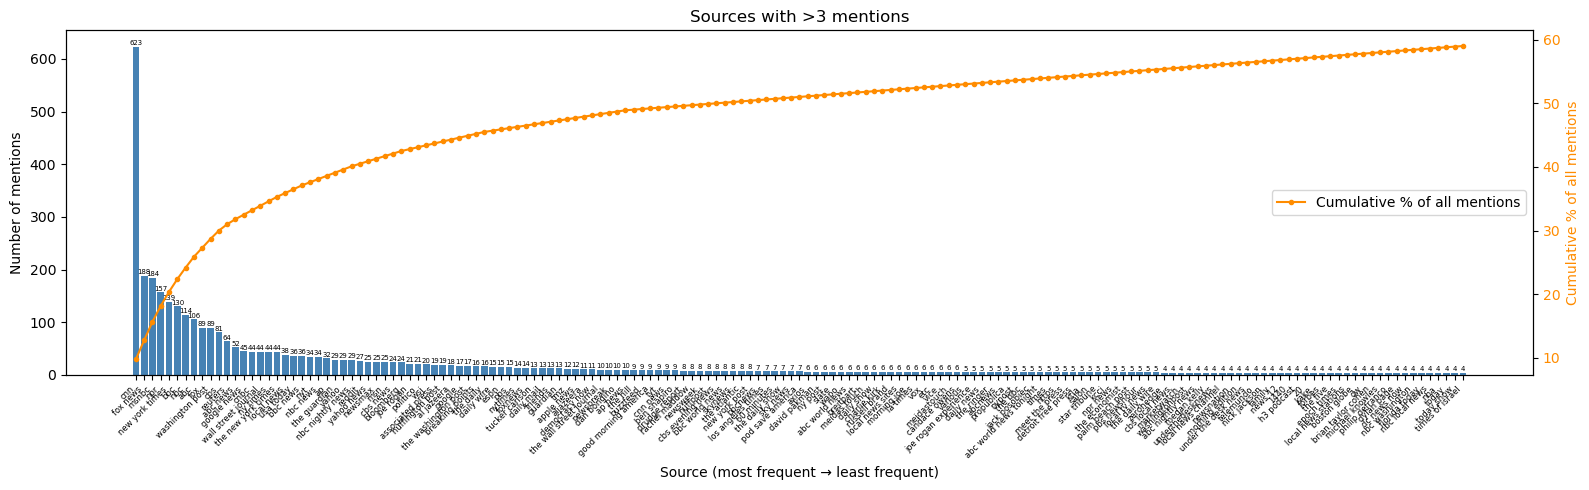

  Top  1 sources cover 623 of 6372 mentions (9.8%)
  Top  5 sources cover 1291 of 6372 mentions (20.3%)
  Top 10 sources cover 1819 of 6372 mentions (28.5%)
  Top 20 sources cover 2311 of 6372 mentions (36.3%)
  Top 40 sources cover 2819 of 6372 mentions (44.2%)
  Top 80 sources cover 3240 of 6372 mentions (50.8%)
  Top 160 sources cover 3625 of 6372 mentions (56.9%)


In [7]:
total_mentions = freq['count'].sum()
top40 = freq.head(161).copy()
top40['pct'] = (top40['count'] / total_mentions * 100).round(1)
top40['cumulative_pct'] = top40['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top40['source'], top40['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Sources with >3 mentions')
plt.xticks(rotation=45, ha='right', fontsize=6)
for bar, val in zip(bars, top40['count']):
    # only label bars wide enough to show the number without overlapping
    if bar.get_width() > 0.3:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=5)

ax2 = ax.twinx()
ax2.plot(top40['source'], top40['cumulative_pct'], color='darkorange',
         marker='o', markersize=3, linewidth=1.5, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

for n in [1, 5, 10, 20, 40, 80, 160]:
    covered = top40.head(n)['count'].sum()
    print(f"  Top {n:2d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")

# Step 3b: How many strings contain 'like' or 'from'?

These are sentences where a source name is embedded after like and from.
We want to know how common it is.

In [8]:
long_strings = all_cleaned

like_mask = long_strings.str.contains(r'\blike\b', regex=True, na=False)
from_mask = long_strings.str.contains(r'\bfrom\b', regex=True, na=False)

print(f"Total cleaned strings:         {len(all_cleaned)}")
print(f"Long strings (>=25 chars):     {len(all_cleaned)} ({len(all_cleaned)/len(all_cleaned)*100:.1f}%)")
print(f"  containing 'like':           {like_mask.sum()}")
print(f"  containing 'from':           {from_mask.sum()}")
print()
print("Sample 'like' sentences:")
for s in long_strings[like_mask].head(8).tolist():
    print(f"  {repr(s)}")
print()
print("Sample 'from' sentences:")
for s in long_strings[from_mask].head(8).tolist():
    print(f"  {repr(s)}")

Total cleaned strings:         6372
Long strings (>=25 chars):     6372 (100.0%)
  containing 'like':           15
  containing 'from':           47

Sample 'like' sentences:
  'show pages that i follow like the black keys'
  'content creators that i follow like arnold'
  'get entertainment news from figures that i follow like arnold'
  'entertainment news like movieweb'
  'entertainment news from various content creators like alanah pearce'
  'news sources on specific issues like woods hole oceanagraphic institute'
  'local news youtube channels like wral'
  'maybe some random other videos like hasan that i only watch occasionally'

Sample 'from' sentences:
  'film news from bands'
  'entertainment news from actors'
  'get entertainment news from figures that i follow like arnold'
  'political news from the majority report'
  'entertainment news from various content creators like alanah pearce'
  'just when it pops up from people i follow'
  'streaming from varoius channels'
  'they p

# Step 4: Extract frequent words from long sentences

Instead of scanning for known names, we take all strings that appear more than times and
look for them as substrings inside the long sentences.
The idea: if 'cnn' is frequent and a sentence contains 'cnn', we extract 'cnn'. 

In [9]:
freq_names = set(freq[freq['count'] >= 4]['source'].tolist()) 
candidate_names = sorted(
    list(freq_names),
    key=len, reverse=True   # longest first — 'new york times' before 'times'
)
print(f"Candidate source names (frequent): {len(candidate_names)}")
print(f"Top 30: {candidate_names[:30]}")

Candidate source names (frequent): 161
Top 30: ['the wall street journal', 'abc world news tonight', 'joe rogan experience', 'good morning america', 'under the desk news', 'the washington post', 'wall street journal', 'local news stations', 'brian taylor cohen', 'detroit free press', 'local news channel', 'the new york times', 'los angeles times', 'cbs evening news', 'pod save america', 'nbc nightly news', 'local news sites', 'associated press', 'underthedesknews', 'abc nightly news', 'morning edition', 'times of israel', 'breaking points', 'michael knowles', 'huffington post', 'palm beach post', 'philip defranco', 'washington post', 'nbc local news', 'the daily show']


In [10]:
def extract_frequent(s, candidates):
    """Return all frequent names found as whole words inside s.
    If multiple candidates match (e.g. 'bbc or cnn'), each match becomes its own
    row via the explode() call below.  If nothing matches, return s unchanged.
    """
    found = [name for name in candidates
             if re.search(r'\b' + re.escape(name) + r'\b', s)]
    return found if found else [s]

# Explode multi-match results so 'bbc or cnn' → two separate rows
step4_series = all_cleaned.apply(lambda s: extract_frequent(s, candidate_names))
all_extracted_step4 = step4_series.explode().reset_index(drop=True)

# How many strings got resolved (changed)?
original_repeated = all_cleaned.loc[all_cleaned.index.repeat(
    step4_series.apply(len)
)].reset_index(drop=True)
resolved_4 = (all_extracted_step4 != original_repeated).sum()
unresolved_4 = len(all_extracted_step4) - resolved_4

print(f"  Rows after explode:             {len(all_extracted_step4)} (was {len(all_cleaned)})")
print(f"  Resolved by frequent-name scan: {resolved_4} ({resolved_4/len(all_extracted_step4)*100:.1f}%)")
print(f"  Still unresolved:               {unresolved_4}")

# Show some resolved examples
examples_4 = pd.DataFrame({
    'Before': original_repeated.values,
    'After':  all_extracted_step4.values
})
resolved_examples = examples_4[examples_4['Before'] != examples_4['After']]
print(f"\nSample resolved:")
with pd.option_context('display.max_colwidth', 90):
    print(resolved_examples.head(15).to_string())

  Rows after explode:             7450 (was 6372)
  Resolved by frequent-name scan: 1578 (21.2%)
  Still unresolved:               5872

Sample resolved:
                                                                 Before    After
16  entertainment news from various content creators like alanah pearce  various
21                                                       new york times    times
23                                                    los angeles times    times
24                                                                abc 7      abc
29                                                          google news   google
31                                                           yahoo news    yahoo
35                                                       new york times    times
39                                                       new york times    times
50                                                             fox news      fox
71                                  

In [11]:
# New frequency table after step 4
freq_4 = all_extracted_step4.value_counts().reset_index()
freq_4.columns = ['source', 'count']
freq_4['cumulative_pct'] = (freq_4['count'].cumsum() / freq_4['count'].sum() * 100).round(1)

top_4 = freq_4[freq_4['count'] >= 4].copy()
unique_before = all_cleaned.nunique()
unique_after_4 = all_extracted_step4.nunique()

print(f"Unique strings before step 4: {unique_before}")
print(f"Unique strings after  step 4: {unique_after_4}")
print(f"Reduced by: {unique_before - unique_after_4} ({(unique_before-unique_after_4)/unique_before*100:.1f}%)")
print()
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_4.to_string())

Unique strings before step 4: 2522
Unique strings after  step 4: 2095
Reduced by: 427 (16.9%)

                      source  count  cumulative_pct
0                        cnn    654             8.8
1                        fox    321            13.1
2                      times    302            17.1
3                        nbc    208            19.9
4                        abc    207            22.7
5                      msnbc    200            25.4
6                        bbc    200            28.1
7                   fox news    196            30.7
8             new york times    193            33.3
9                        npr    192            35.9
10                       cbs    138            37.7
11           washington post    110            39.2
12                local news    105            40.6
13                    google     82            41.7
14                     today     67            42.6
15                   reuters     65            43.5
16                   

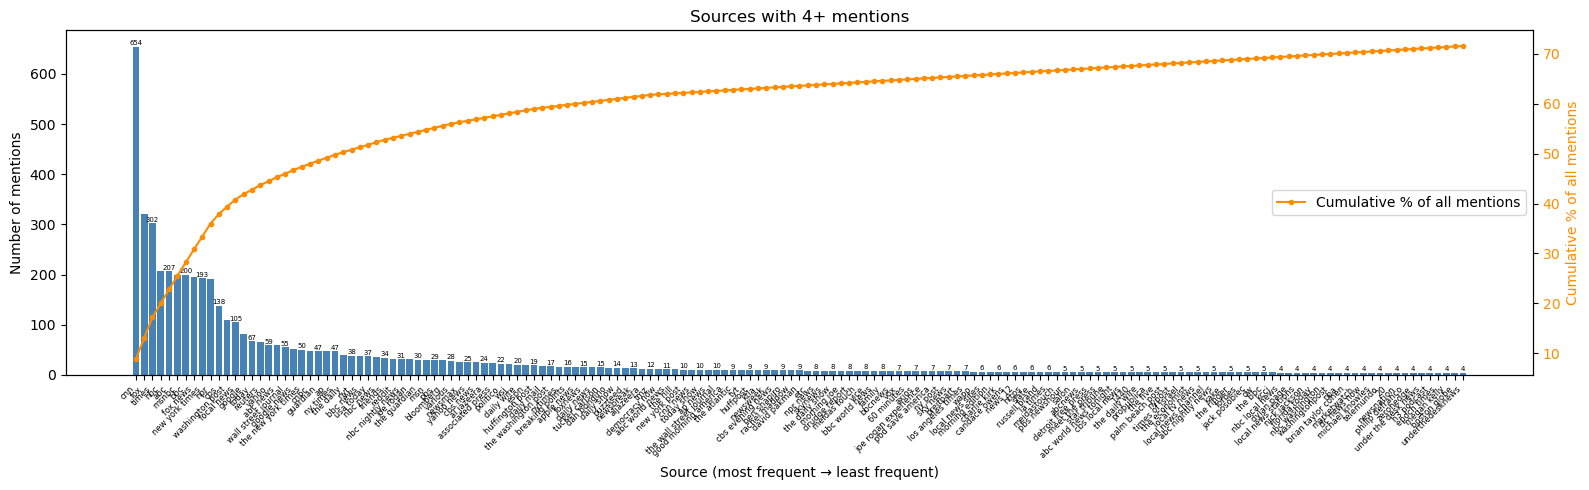

Total mentions in dataset: 7450

  Top  1 sources cover 654 of 7450 mentions (8.8%)
  Top  5 sources cover 1692 of 7450 mentions (22.7%)
  Top 10 sources cover 2673 of 7450 mentions (35.9%)
  Top 20 sources cover 3465 of 7450 mentions (46.5%)
  Top 40 sources cover 4191 of 7450 mentions (56.3%)
  Top 80 sources cover 4759 of 7450 mentions (63.9%)
  Top 161 sources cover 5207 of 7450 mentions (69.9%)


In [12]:
total_mentions = freq_4['count'].sum()
top40 = freq_4.head(161).copy()
top40['pct'] = (top40['count'] / total_mentions * 100).round(1)
top40['cumulative_pct'] = top40['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top40['source'], top40['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Sources with 4+ mentions')
plt.xticks(rotation=45, ha='right', fontsize=6)
for i, (bar, val) in enumerate(zip(bars, top40['count'])):
    if i % 2 == 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=5)

ax2 = ax.twinx()
ax2.plot(top40['source'], top40['cumulative_pct'], color='darkorange',
         marker='o', markersize=3, linewidth=1.5, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step3.png', dpi=150)
plt.show()

print(f"Total mentions in dataset: {total_mentions}")
print()
for n in [1, 5, 10, 20, 40, 80, 161]:
    covered = top40.head(n)['count'].sum()
    print(f"  Top {n:2d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")

# Step 5 Since most of extracted sources are mainstream media, we'll need to analyse social-media 

What did people actually write in the Facebook / Instagram / TikTok / Twitter / YouTube columns?

We expect SM platform names — but some people wrote mainstream media sources there (e.g. 'CNN' in the YouTube column).
This is 'MM-in-SM': they consume news via a social media platform.
We also check how much is genuine noise (non-news junk).

In [31]:
sm_col_entries = exploded[exploded['col_type'] == 'SM_col']['cleaned'].copy()
# Apply the extraction we've done so far (now returns lists → explode)
sm_col_entries_extracted = (
    sm_col_entries
    .apply(lambda s: extract_frequent(s, candidate_names))
    .explode()
    .reset_index(drop=True)
)

sm_freq = sm_col_entries_extracted.value_counts().reset_index()
sm_freq.columns = ['source', 'count']

# MM-in-SM: known MM sources that appeared in SM columns
mm_in_sm = sm_freq[sm_freq['source'].isin(candidate_names)].copy()

# SM-specific: strings not already in candidate_names
sm_specific = sm_freq[~sm_freq['source'].isin(candidate_names)].copy()

print(f"All SM column entries: {len(sm_col_entries_extracted)}")
print(f"MM-in-SM sources: {len(mm_in_sm)}")
print(f"SM-specific sources: {len(sm_specific)}")

print(mm_in_sm)
print(sm_specific)
 

All SM column entries: 2850
MM-in-SM sources: 144
SM-specific sources: 1087
               source  count
0                 cnn    241
1                 bbc    102
2                 fox     99
3               times     73
4               msnbc     68
...               ...    ...
1097  palm beach post      1
1120          the bbc      1
1130        telemundo      1
1133         the five      1
1229             1440      1

[144 rows x 2 columns]
                    source  count
79               penguinz0      3
81               joe biden      3
82                     rap      3
83    no specific accounts      3
87                the view      3
...                    ...    ...
1225            wavy tv 10      1
1226   the virginian pilot      1
1227            13news now      1
1228           wtkr news 3      1
1230                 music      1

[1087 rows x 2 columns]


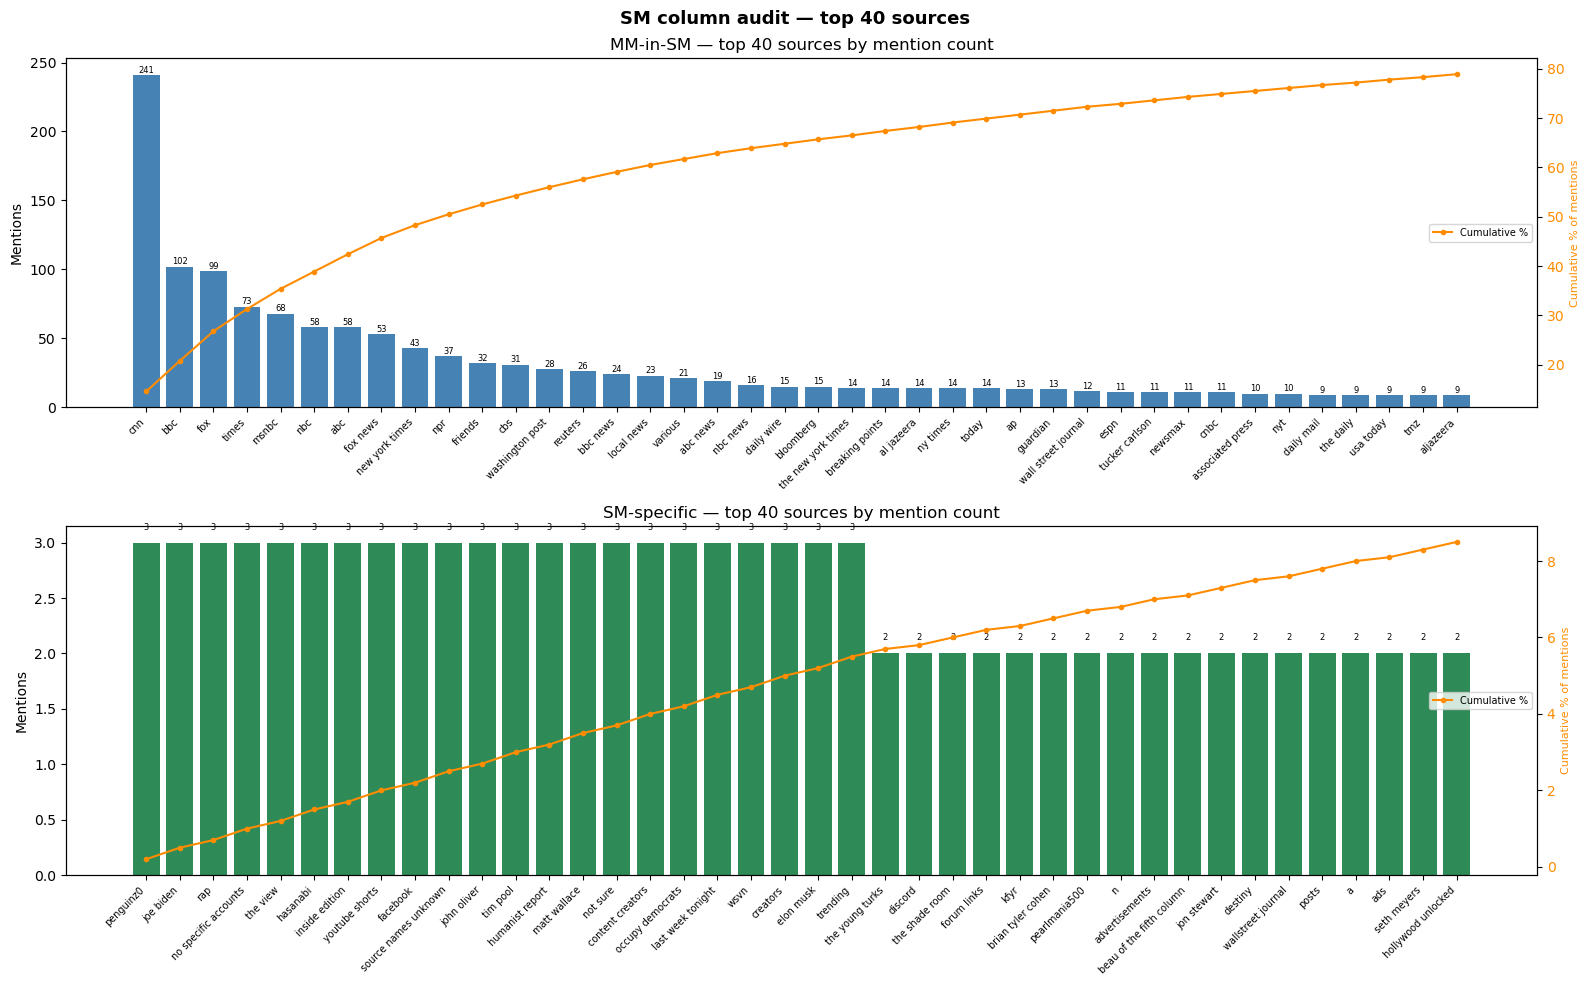

In [32]:
# Top-40 bar charts: MM-in-SM (top) and SM-specific (bottom)
# Cumulative % orange line on twin axis — matches Step 3a / SM Steps 1-3 style

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('SM column audit — top 40 sources', fontsize=13, fontweight='bold')

for ax, (df, label, colour) in zip(axes, [
    (mm_in_sm,    'MM-in-SM',    'steelblue'),
    (sm_specific, 'SM-specific', 'seagreen'),
]):
    top_n = df.head(40).copy()
    total = df['count'].sum()
    top_n['cumulative_pct'] = (top_n['count'].cumsum() / total * 100).round(1)

    bars = ax.bar(range(len(top_n)), top_n['count'], color=colour)
    ax.set_xticks(range(len(top_n)))
    ax.set_xticklabels(top_n['source'], rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Mentions')
    ax.set_title(f'{label} — top {len(top_n)} sources by mention count')
    for bar, val in zip(bars, top_n['count']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                str(val), ha='center', va='bottom', fontsize=6)

    ax2 = ax.twinx()
    ax2.plot(range(len(top_n)), top_n['cumulative_pct'],
             color='darkorange', marker='o', markersize=3, linewidth=1.5,
             label='Cumulative %')
    ax2.set_ylabel('Cumulative % of mentions', color='darkorange', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.legend(loc='center right', fontsize=7)

plt.tight_layout()
plt.savefig('sm_audit_top40.png', dpi=150)
plt.show()


# Step 5b: Unify social-media-specific sources

These are strings found in social-media survey columns (Facebook, Instagram, TikTok, Twitter/X, YouTube)
that are NOT already in our mainstream-media candidate list.

There are ~1075 unique strings, but most appear only once.
We work through four steps, each measured for effectiveness:
1. Hardcoded alias map for known SM accounts and their variant spellings
2. Platform-prefix strip (e.g. 'youtube - penguinz0' → 'penguinz0')
3. Noise filter — remove strings that are clearly not sources (junk phrases, single letters, generic words)
4. Normalise spacing/punctuation so 'john oliver' and 'john  oliver' merge

After each step: frequency table (2+ mentions) + chart showing unique-string reduction.

In [14]:
# Starting point: SM-specific strings after step 5
# sm_col_entries_extracted and sm_specific were built in step 5
# sm_specific = strings from SM columns that are NOT in candidate_names (known MM sources)

# Turn sm_specific (a frequency dataframe) back into a flat series
# so we can apply the same per-string transformations step by step
# We reconstruct it from sm_col_entries_extracted, excluding known MM sources
known_mm_set = set(candidate_names)
sm_only = sm_col_entries_extracted[
    ~sm_col_entries_extracted.isin(known_mm_set)
].reset_index(drop=True)
 
freq_sm0 = sm_only.value_counts().reset_index()
freq_sm0.columns = ['source', 'count']
print(f"Starting SM-specific unique strings: {sm_only.nunique()}")
print(f"Mentioned 2+ times: {(freq_sm0['count'] >= 2).sum()}")
print()
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 80):
    print(freq_sm0[freq_sm0['count'] >= 2].to_string())

Starting SM-specific unique strings: 1087
Mentioned 2+ times: 94

                                         source  count
0                                      facebook      3
1                                   john oliver      3
2                                      not sure      3
3                                     penguinz0      3
4                              content creators      3
5                                      trending      3
6                                  matt wallace      3
7                                      tim pool      3
8                                     joe biden      3
9                                     elon musk      3
10                              humanist report      3
11                            last week tonight      3
12                                     creators      3
13                             occupy democrats      3
14                         source names unknown      3
15                                         wsvn      3

## SM Step 1: Hardcoded alias map for known SM accounts

Manually researched: known social media news accounts and influencers with variant spellings.
Same approach as the MM ALIAS_MAP — more specific patterns before general ones.

Sources included:
- Platform aliases (fb, ig, yt, x.com)
- Misspellings found in the data (penguinz0 / moistcr1tikal, hasanabi / hasan piker)
- Variant spellings (young turks / the young turks, zero hedge / zerohedge)
- Noise that looks like a source but isn't (junk handled in SM Step 3)

In [15]:
# Hardcoded aliases for SM-specific sources
# Pattern → standard name
SM_ALIAS_MAP = [
    # Platform names and aliases
    (r'\bfacebook\b',                   'Facebook'),
    (r'\bfb\b',                         'Facebook'),
    (r'\bfacebook\s+news\b',            'Facebook'),
    (r'\binstagram\b',                  'Instagram'),
    (r'\big\b(?!n)',                    'Instagram'),
    (r'\btiktok\b',                     'TikTok'),
    (r'\btwitter\b',                    'Twitter/X'),
    (r'\bx\.com\b',                     'Twitter/X'),
    (r'\byoutube\b',                    'YouTube'),
    (r'\byoutube\s+shorts\b',           'YouTube'),
    (r'\byt\b',                         'YouTube'),
    (r'\breddit\b',                     'Reddit'),
    (r'\bsnapchat\b',                   'Snapchat'),
    (r'\bdiscord\b',                    'Discord'),
    (r'\bthreads\b',                    'Threads'),
    (r'\bbluesky\b',                    'Bluesky'),
    (r'\bmastodon\b',                   'Mastodon'),
    (r'\btwitch\b',                     'Twitch'),

    # The Young Turks — multiple spellings
    (r'\bthe\s+young\s+turks\b',        'TYT'),
    (r'\byoung\s+turks\b',              'TYT'),
    (r'\btyt\b',                        'TYT'),

    # Hasan Piker / Hasanabi
    (r'\bhasanabi\b',                   'Hasanabi'),
    (r'\bhasan\s+piker\b',              'Hasanabi'),
    (r'\bhasan\b(?!\s+rouhani)',        'Hasanabi'),  # 'hasan' alone but not 'hasan rouhani'

    # Penguinz0 / MoistCr1TiKaL
    (r'\bpenguinz0\b',                  'Penguinz0'),
    (r'\bmoist\s*cr1tikal\b',           'Penguinz0'),
    (r'\bmoistikal\b',                  'Penguinz0'),

    # ZeroHedge — spacing variant
    (r'\bzero\s+hedge\b',               'ZeroHedge'),
    (r'\bzerohedge\b',                  'ZeroHedge'),

    # The Humanist Report — with/without 'the'
    (r'\bthe\s+humanist\s+report\b',    'Humanist Report'),
    (r'\bhumanist\s+report\b',          'Humanist Report'),

    # The Shade Room
    (r'\bthe\s+shade\s+room\b',         'The Shade Room'),
    (r'\bshade\s+room\b',               'The Shade Room'),

    # The Athletic
    (r'\bthe\s+athletic\b',             'The Athletic'),
    (r'\bathletic\b',                   'The Athletic'),

    # The View
    (r'\bthe\s+view\b',                 'The View'),

    # Occupy Democrats
    (r'\boccupy\s+democrats\b',         'Occupy Democrats'),

    # The Rational National
    (r'\bthe\s+rational\s+national\b',  'The Rational National'),
    (r'\brational\s+national\b',        'The Rational National'),

    # Some More News
    (r'\bsome\s+more\s+news\b',         'Some More News'),

    # Brian Tyler Cohen
    (r'\bbrian\s+tyler\s+cohen\b',      'Brian Tyler Cohen'),

    # Beau of the Fifth Column
    (r'\bbeau\s+of\s+the\s+fifth\s+column\b', 'Beau of the Fifth Column'),

    # Majority Report
    (r'\bmajority\s+report\b',          'Majority Report'),

    # Secular Talk
    (r'\bsecular\s+talk\b',             'Secular Talk'),

    # Jon Stewart / Seth Meyers (commentators)
    (r'\bjon\s+stewart\b',              'Jon Stewart'),
    (r'\bjohn\s+stewart\b',             'Jon Stewart'),   # common misspelling
    (r'\bseth\s+mey[oe]rs?\b',          'Seth Meyers'),  # meyers/meers/myers

    # John Oliver / Last Week Tonight (same show)
    (r'\bjohn\s+oliver\b',              'John Oliver'),
    (r'\blast\s+week\s+tonight\b',      'John Oliver'),   # his show = him

    # Tim Pool
    (r'\btim\s+pool\b',                 'Tim Pool'),
    (r'\btimcast\b',                    'Tim Pool'),

    # Mark Dice
    (r'\bmark\s+dice\b',                'Mark Dice'),

    # Andy Ngo
    (r'\bandy\s+ngo\b',                 'Andy Ngo'),

    # Matt Walsh / Matt Wallace (different people, keep separate)
    (r'\bmatt\s+walsh\b',               'Matt Walsh'),
    (r'\bmatt\s+wallace\b',             'Matt Wallace'),

    # Elon Musk (appears as source in SM context)
    (r'\belon\s+musk\b',                'Elon Musk'),
    (r'\belonmusk\b',                   'Elon Musk'),

    # Jordan Peterson
    (r'\bjordan\s+peterson\b',          'Jordan Peterson'),

    # George Conway
    (r'\bgeorge\s+conway\b',            'George Conway'),

    # Glenn Greenwald — misspelling 'glen'
    (r'\bglenn?\s+greenwald\b',         'Glenn Greenwald'),

    # Jonathan Turley
    (r'\bjonathan\s+turley\b',          'Jonathan Turley'),

    # C-SPAN
    (r'\bcspan\b',                      'C-SPAN'),
    (r'\bc-span\b',                     'C-SPAN'),

    # Inside Edition
    (r'\binside\s+edition\b',           'Inside Edition'),

    # Hollywood Unlocked
    (r'\bhollywood\s+unlocked\b',       'Hollywood Unlocked'),

    # MeidasTouch
    (r'\bmeidas\s*touch\b',             'MeidasTouch'),

    # Barstool Sports
    (r'\bbarstool\s+sports\b',          'Barstool Sports'),
    (r'\bbarstool\b',                   'Barstool Sports'),

    # BNO News
    (r'\bbno\s+news\b',                 'BNO News'),
    (r'\bbnonews\b',                    'BNO News'),

    # WION
    (r'\bwion\b',                       'WION'),

    # Redacted (YouTube channel)
    (r'\bredacted\b',                   'Redacted'),

    # The News Girl
    (r'\bthe\s+news\s+girl\b',          'The News Girl'),

    # Wallstreet Journal variant (misspelling, should be WSJ)
    (r'\bwallstreet\s+journal\b',       'Wall Street Journal'),
    (r'\bwall\s+street\s+journal\b',    'Wall Street Journal'),
]

def unify_sm(s):
    for pattern, name in SM_ALIAS_MAP:
        if re.search(pattern, s):
            return name
    return s

sm_step1 = sm_only.apply(unify_sm)

changed_1 = (sm_step1 != sm_only).sum()
unique_before_1 = sm_only.nunique()
unique_after_1  = sm_step1.nunique()

print(f"Step 1 — hardcoded aliases")
print(f"  Strings changed:  {changed_1}")
print(f"  Unique before:    {unique_before_1}")
print(f"  Unique after:     {unique_after_1}")
print(f"  Reduced by:       {unique_before_1 - unique_after_1} ({(unique_before_1-unique_after_1)/unique_before_1*100:.1f}%)")

# Show what changed
mask_1 = sm_step1 != sm_only
ex1 = pd.DataFrame({'Before': sm_only[mask_1].values, 'After': sm_step1[mask_1].values}).drop_duplicates()
print(f"\nChanged pairs ({len(ex1)}):")
with pd.option_context('display.max_colwidth', 60):
    print(ex1.to_string())

Step 1 — hardcoded aliases
  Strings changed:  155
  Unique before:    1087
  Unique after:     1031
  Reduced by:       56 (5.2%)

Changed pairs (98):
                                                                                                                                                                                        Before                     After
0                                                                                                                                                      political news from the majority report           Majority Report
1                                                                                                                                                                                     facebook                  Facebook
2                                                                                                                                                                                  john oliver       

In [16]:
# Frequency table after SM Step 1
freq_sm1 = sm_step1.value_counts().reset_index()
freq_sm1.columns = ['source', 'count']
print(f"Unique SM-specific strings after step 1: {sm_step1.nunique()}")
print(f"Mentioned 2+ times: {(freq_sm1['count'] >= 2).sum()}")
print()
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 80):
    print(freq_sm1[freq_sm1['count'] >= 2].to_string())

Unique SM-specific strings after step 1: 1031
Mentioned 2+ times: 92

                                         source  count
0                                      Facebook     23
1                                     Twitter/X     10
2                                       YouTube      7
3                                   John Oliver      7
4                                     Elon Musk      6
5                               Majority Report      6
6                                        TikTok      5
7                               Humanist Report      5
8                                     Instagram      5
9                                      Hasanabi      5
10                                 Matt Wallace      4
11                                          TYT      4
12                               Inside Edition      3
13                         no specific accounts      3
14                                  Seth Meyers      3
15                                    joe biden   

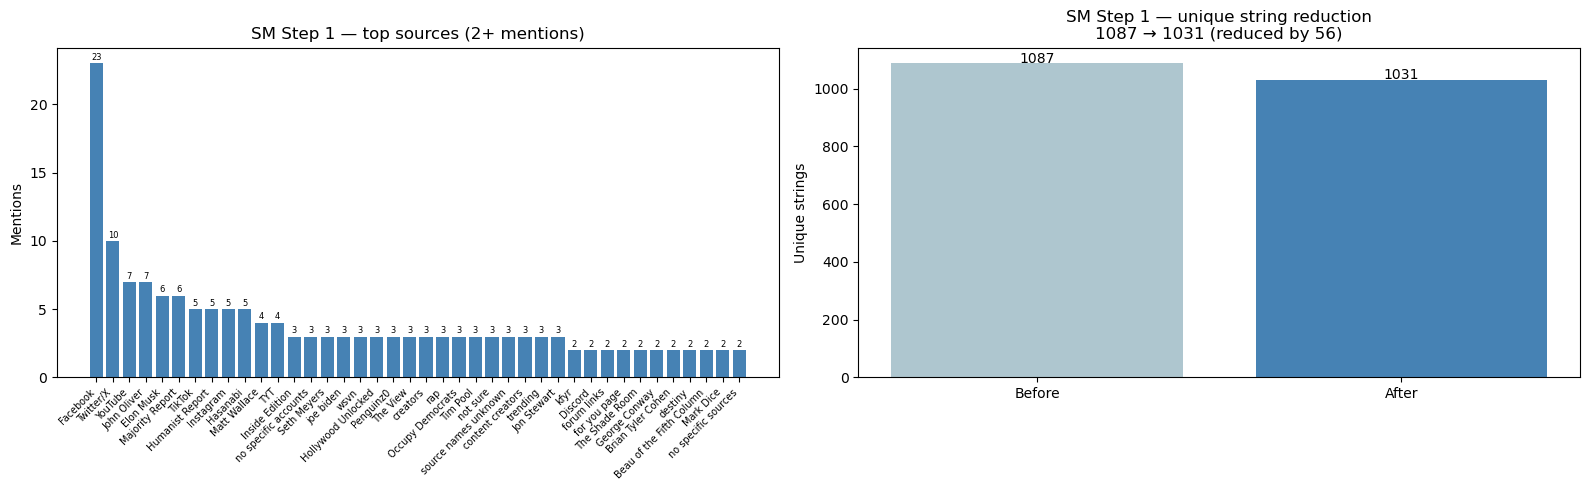


Strings with 2+ mentions NOT caught by alias map: 50
These are edge cases the alias map missed:
                     source  count
13     no specific accounts      3
15                joe biden      3
16                     wsvn      3
20                 creators      3
21                      rap      3
24                 not sure      3
25     source names unknown      3
26         content creators      3
27                 trending      3
29                     kfyr      2
31              forum links      2
32             for you page      2
36                  destiny      2
39      no specific sources      2
40                     them      2
41                 masslive      2
42            random people      2
44             sharonsaysso      2
48           advertisements      2
49                news feed      2
51           united nations      2
52                        n      2
53                        a      2
54  independent journalists      2
56                worldstar 

In [17]:
# Chart after SM Step 1
unique_b1 = sm_only.nunique()
unique_a1 = sm_step1.nunique()
freq_sm1_top = freq_sm1[freq_sm1['count'] >= 2].head(40)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(range(len(freq_sm1_top)), freq_sm1_top['count'], color='steelblue')
axes[0].set_xticks(range(len(freq_sm1_top)))
axes[0].set_xticklabels(freq_sm1_top['source'], rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Mentions')
axes[0].set_title('SM Step 1 — top sources (2+ mentions)')
for bar, val in zip(bars, freq_sm1_top['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', va='bottom', fontsize=6)

axes[1].bar(['Before', 'After'], [unique_b1, unique_a1], color=['#aec6cf', 'steelblue'])
axes[1].set_ylabel('Unique strings')
axes[1].set_title(f'SM Step 1 — unique string reduction\n{unique_b1} → {unique_a1} (reduced by {unique_b1-unique_a1})')
for i, v in enumerate([unique_b1, unique_a1]):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('sm_step1.png', dpi=150)
plt.show()

# What did NOT get unified — check edge cases the alias map missed
still_multi_1 = freq_sm1[(freq_sm1['count'] >= 2) & (~freq_sm1['source'].isin([n for _,n in SM_ALIAS_MAP]))]
print(f"\nStrings with 2+ mentions NOT caught by alias map: {len(still_multi_1)}")
print("These are edge cases the alias map missed:")
with pd.option_context('display.max_colwidth', 80):
    print(still_multi_1.head(30).to_string())
print()
print("Recommendation: alias map works well for known accounts but misses unknown local/niche accounts.")
print("These should go through SM Step 2 (platform-prefix strip) or be left as-is.")

## SM Step 2: Strip platform prefix

Some respondents write 'youtube - penguinz0' or 'tiktok: beau of the fifth column'.
We strip the platform name and separator to get just the account name.

This is a targeted rule — only fires when a known platform word is at the start.

In [18]:
# Strip platform prefix like 'youtube - ', 'tiktok: ', 'ig: ', 'fb/'
PLATFORM_PREFIXES = r'^(?:youtube|tiktok|instagram|ig|facebook|fb|twitter|x|reddit|snapchat)\s*[-:./]\s*'

def strip_platform_prefix(s):
    return re.sub(PLATFORM_PREFIXES, '', s, flags=re.IGNORECASE).strip()

sm_step2 = sm_step1.apply(strip_platform_prefix)

changed_2 = (sm_step2 != sm_step1).sum()
unique_b2 = sm_step1.nunique()
unique_a2 = sm_step2.nunique()

print(f"Step 2 — platform prefix strip")
print(f"  Strings changed: {changed_2}")
print(f"  Unique before:   {unique_b2}")
print(f"  Unique after:    {unique_a2}")
print(f"  Reduced by:      {unique_b2 - unique_a2} ({(unique_b2-unique_a2)/unique_b2*100:.1f}%)")

mask_2 = sm_step2 != sm_step1
ex2 = pd.DataFrame({'Before': sm_step1[mask_2].values, 'After': sm_step2[mask_2].values}).drop_duplicates()
print(f"\nAll changed pairs ({len(ex2)}):")
with pd.option_context('display.max_colwidth', 80):
    print(ex2.to_string())

Step 2 — platform prefix strip
  Strings changed: 10
  Unique before:   1031
  Unique after:    1031
  Reduced by:      0 (0.0%)

All changed pairs (1):
      Before After
0  Twitter/X     X


In [19]:
# Frequency table after SM Step 2
freq_sm2 = sm_step2.value_counts().reset_index()
freq_sm2.columns = ['source', 'count']
print(f"Unique SM-specific strings after step 2: {sm_step2.nunique()}")
print(f"Mentioned 2+ times: {(freq_sm2['count'] >= 2).sum()}")
print()
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 80):
    print(freq_sm2[freq_sm2['count'] >= 2].to_string())

Unique SM-specific strings after step 2: 1031
Mentioned 2+ times: 92

                                         source  count
0                                      Facebook     23
1                                             X     10
2                                       YouTube      7
3                                   John Oliver      7
4                                     Elon Musk      6
5                               Majority Report      6
6                                        TikTok      5
7                               Humanist Report      5
8                                     Instagram      5
9                                      Hasanabi      5
10                                 Matt Wallace      4
11                                          TYT      4
12                               Inside Edition      3
13                         no specific accounts      3
14                                  Seth Meyers      3
15                                    joe biden   

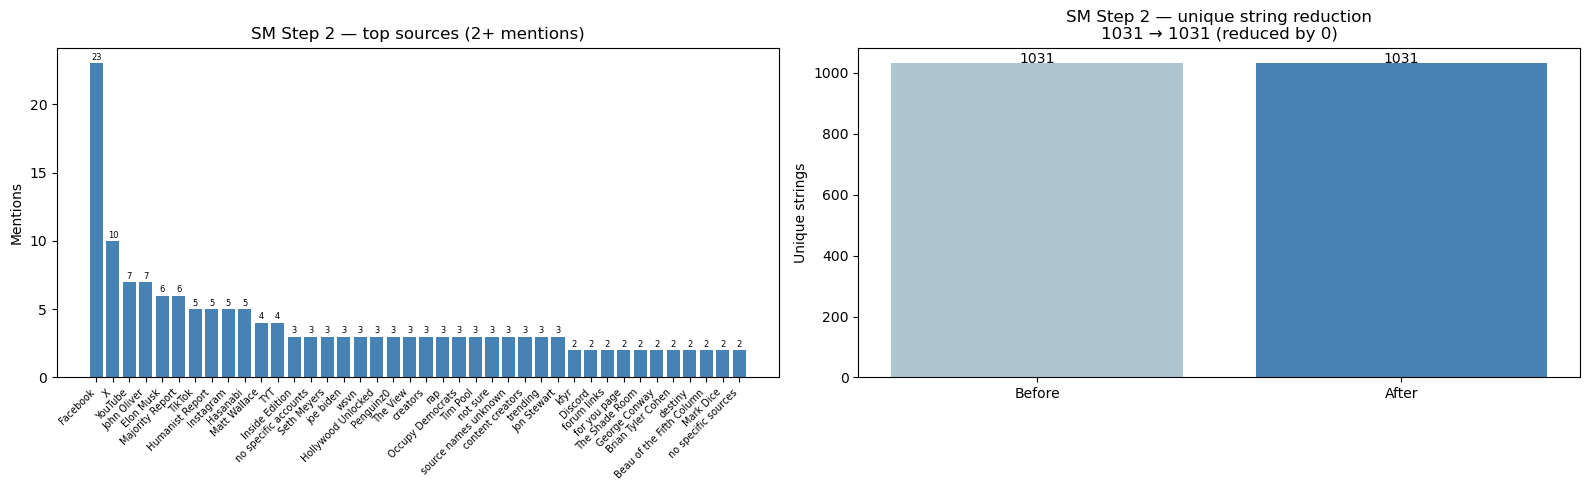


Potential over-stripping (result is too short/generic): 0
None found.

Recommendation: platform-prefix strip is safe — it only fires when a known
platform word is literally at the start followed by a separator. Low false-positive risk.


In [20]:
# Chart after SM Step 2
freq_sm2_top = freq_sm2[freq_sm2['count'] >= 2].head(40)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(range(len(freq_sm2_top)), freq_sm2_top['count'], color='steelblue')
axes[0].set_xticks(range(len(freq_sm2_top)))
axes[0].set_xticklabels(freq_sm2_top['source'], rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Mentions')
axes[0].set_title('SM Step 2 — top sources (2+ mentions)')
for bar, val in zip(bars, freq_sm2_top['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', va='bottom', fontsize=6)

axes[1].bar(['Before', 'After'], [unique_b2, unique_a2], color=['#aec6cf', 'steelblue'])
axes[1].set_ylabel('Unique strings')
axes[1].set_title(f'SM Step 2 — unique string reduction\n{unique_b2} → {unique_a2} (reduced by {unique_b2-unique_a2})')
for i, v in enumerate([unique_b2, unique_a2]):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('sm_step2.png', dpi=150)
plt.show()

# Edge cases: did it wrongly strip platform names that were genuine sources?
wrong_strip = ex2[ex2['After'].isin(['', 'shorts', 'news', 'live'])]
print(f"\nPotential over-stripping (result is too short/generic): {len(wrong_strip)}")
if len(wrong_strip):
    print(wrong_strip.to_string())
else:
    print("None found.")
print()
print("Recommendation: platform-prefix strip is safe — it only fires when a known")
print("platform word is literally at the start followed by a separator. Low false-positive risk.")

## SM Step 3: Noise filter

Remove strings that are clearly not source names:
- Generic phrases ('for you page', 'just following links', 'random people', etc.)
- Single letters or numbers
- Pure junk ('n/a', 'nothing specific', etc.)

These get replaced with a sentinel value 'NOISE' so we can count them and exclude later.
We do NOT delete rows — we keep them as NOISE so the count stays consistent.

In [21]:
SM_NOISE_EXACT = {
    'n/a', 'na', 'n', 'a', 'no', 'none', 'nothing', 'not sure',
    'various', 'many', 'other', 'others', 'posts', 'ads', 'them',
    'users', 'content', 'creators', 'trending', 'explore page',
    'news feed', 'for you page', 'my feed', 'impact',
    'no specific sources', 'no specific accounts', 'not specific',
    'nothing specific', 'nothing specific at all', 'source names unknown',
    'independent journalists', 'random people', 'forum links',
    'advertisements', 'just following links from elsewhere',
    'only what shows up in my feed', 'i just read my feed',
    'random people who appear on my for you page',
    'rap', 'democrats', 'newstoday', 'america news',
}

SM_NOISE_PATTERNS = [
    r'^\d+$',                           # pure number
    r'^[a-z]$',                         # single letter
    r'\bjust\s+follow',                 # 'just following links...'
    r'\bonly\s+what\s+shows',           # 'only what shows up...'
    r'\brandom\s+people\b',             # 'random people'
    r'\bfor\s+you\s+page\b',            # 'for you page'
    r'\bmy\s+feed\b',                   # 'my feed'
    r'\bnews\s+feed\b',                 # 'news feed'
    r'\bno\s+specific\b',               # 'no specific ...'
    r'\bnothing\s+specific\b',          # 'nothing specific'
    r'\bsource\s+names\s+unknown\b',    # 'source names unknown'
]

def is_noise_sm(s):
    if s in SM_NOISE_EXACT:
        return True
    for pat in SM_NOISE_PATTERNS:
        if re.search(pat, s):
            return True
    return False

sm_step3 = sm_step2.apply(lambda s: 'NOISE' if is_noise_sm(s) else s)

noise_count = (sm_step3 == 'NOISE').sum()
changed_3   = (sm_step3 != sm_step2).sum()
unique_b3   = sm_step2.nunique()
unique_a3   = sm_step3[sm_step3 != 'NOISE'].nunique()

print(f"Step 3 — noise filter")
print(f"  Strings flagged as NOISE: {noise_count} ({noise_count/len(sm_step3)*100:.1f}%)")
print(f"  Unique before (excl. NOISE): {unique_b3}")
print(f"  Unique after  (excl. NOISE): {unique_a3}")
print(f"  Reduced by: {unique_b3 - unique_a3}")

# Show what got flagged
noise_flagged = freq_sm2[freq_sm2['source'].apply(is_noise_sm)]
print(f"\\nNoise strings with 2+ mentions:")
with pd.option_context('display.max_colwidth', 80):
    print(noise_flagged[noise_flagged['count'] >= 2].to_string())

Step 3 — noise filter
  Strings flagged as NOISE: 99 (8.2%)
  Unique before (excl. NOISE): 1031
  Unique after  (excl. NOISE): 969
  Reduced by: 62
\nNoise strings with 2+ mentions:
                                         source  count
13                         no specific accounts      3
20                                     creators      3
21                                          rap      3
24                                     not sure      3
25                         source names unknown      3
27                                     trending      3
31                                  forum links      2
32                                 for you page      2
39                          no specific sources      2
40                                         them      2
42                                random people      2
48                               advertisements      2
49                                    news feed      2
52                                            n 

In [22]:
# Frequency table after SM Step 3 (excluding NOISE)
sm_step3_clean = sm_step3[sm_step3 != 'NOISE']
freq_sm3 = sm_step3_clean.value_counts().reset_index()
freq_sm3.columns = ['source', 'count']
print(f"Unique SM-specific strings after step 3 (excl. NOISE): {sm_step3_clean.nunique()}")
print(f"Mentioned 2+ times: {(freq_sm3['count'] >= 2).sum()}")
print()
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 80):
    print(freq_sm3[freq_sm3['count'] >= 2].to_string())

Unique SM-specific strings after step 3 (excl. NOISE): 969
Mentioned 2+ times: 61

                      source  count
0                   Facebook     23
1                          X     10
2                    YouTube      7
3                John Oliver      7
4            Majority Report      6
5                  Elon Musk      6
6            Humanist Report      5
7                   Hasanabi      5
8                     TikTok      5
9                  Instagram      5
10              Matt Wallace      4
11                       TYT      4
12        Hollywood Unlocked      3
13                      wsvn      3
14               Seth Meyers      3
15          content creators      3
16               Jon Stewart      3
17                  The View      3
18            Inside Edition      3
19                 Penguinz0      3
20                 joe biden      3
21          Occupy Democrats      3
22                  Tim Pool      3
23         Brian Tyler Cohen      2
24              s

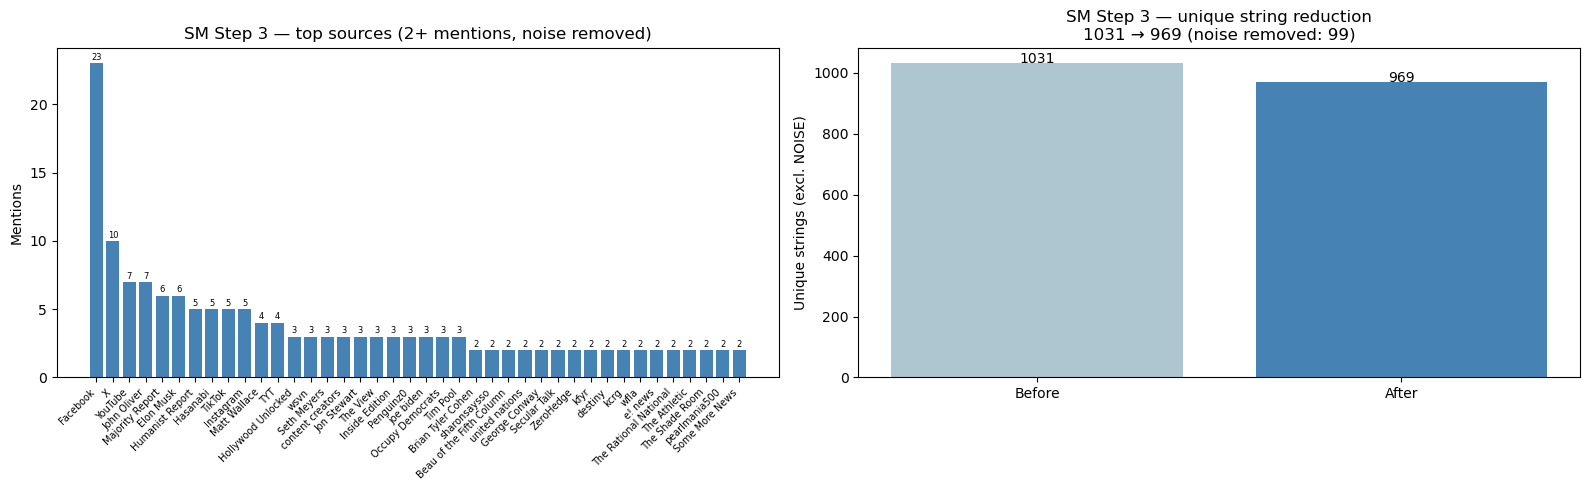


Surviving strings with 3 or fewer characters (potential noise):
    source  count
1        X     10
11     TYT      4
49     any      2
63     sly      1
72     ksl      1
129    who      1
166    twp      1
334    bcc      1
377    pnj      1
448    law      1
455    tnt      1
502    wjz      1
511    fow      1
563    nhl      1
691    pew      1
703    run      1
817    itv      1
818     e!      1
819    sky      1
878     al      1
881    eyl      1
910    mlb      1
914    nih      1
947    upi      1
962    voa      1

Recommendation: noise filter handles generic phrases well.
Edge case risk: might over-filter legitimate niche sources with generic names.
Mitigation: only filter exact matches or very specific patterns — keep regex tight.


In [23]:
# Chart after SM Step 3
freq_sm3_top = freq_sm3[freq_sm3['count'] >= 2].head(40)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(range(len(freq_sm3_top)), freq_sm3_top['count'], color='steelblue')
axes[0].set_xticks(range(len(freq_sm3_top)))
axes[0].set_xticklabels(freq_sm3_top['source'], rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Mentions')
axes[0].set_title('SM Step 3 — top sources (2+ mentions, noise removed)')
for bar, val in zip(bars, freq_sm3_top['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', va='bottom', fontsize=6)

axes[1].bar(['Before', 'After'], [unique_b3, unique_a3], color=['#aec6cf', 'steelblue'])
axes[1].set_ylabel('Unique strings (excl. NOISE)')
axes[1].set_title(f'SM Step 3 — unique string reduction\n{unique_b3} → {unique_a3} (noise removed: {noise_count})')
for i, v in enumerate([unique_b3, unique_a3]):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('sm_step3.png', dpi=150)
plt.show()

# Edge cases: what short strings survived that might be noise?
survived_short = freq_sm3[freq_sm3['source'].str.len() <= 3]
print(f"\nSurviving strings with 3 or fewer characters (potential noise):")
with pd.option_context('display.max_colwidth', 40):
    print(survived_short.to_string())
print()
print("Recommendation: noise filter handles generic phrases well.")
print("Edge case risk: might over-filter legitimate niche sources with generic names.")
print("Mitigation: only filter exact matches or very specific patterns — keep regex tight.")

## SM Step 4: Normalise spacing and punctuation

People type inconsistently: 'john  oliver' (double space), 'the-view' (hyphen), '@sharonsaysso'.
Collapse multiple spaces to one, strip leading @ and #, replace hyphens with spaces where sensible.

In [24]:
def normalise_spacing(s):
    if s == 'NOISE':
        return s
    s = re.sub(r'^[@#]', '', s)           # strip leading @ or #
    s = re.sub(r'\s+', ' ', s)            # collapse multiple spaces
    s = re.sub(r'\s*-\s*', ' ', s)        # hyphen → space (e.g. 'the-view' → 'the view')
    s = s.strip()
    return s

sm_step4 = sm_step3.apply(normalise_spacing)

changed_4 = (sm_step4 != sm_step3).sum()
unique_b4  = sm_step3[sm_step3 != 'NOISE'].nunique()
unique_a4  = sm_step4[sm_step4 != 'NOISE'].nunique()

print(f"Step 4 — normalise spacing/punctuation")
print(f"  Strings changed: {changed_4}")
print(f"  Unique before:   {unique_b4}")
print(f"  Unique after:    {unique_a4}")
print(f"  Reduced by:      {unique_b4 - unique_a4}")

mask_4 = (sm_step4 != sm_step3) & (sm_step3 != 'NOISE')
ex4 = pd.DataFrame({'Before': sm_step3[mask_4].values, 'After': sm_step4[mask_4].values}).drop_duplicates()
print(f"\nAll changed pairs ({len(ex4)}):")
with pd.option_context('display.max_colwidth', 80):
    print(ex4.to_string() if len(ex4) else "None changed.")

Step 4 — normalise spacing/punctuation
  Strings changed: 17
  Unique before:   969
  Unique after:    969
  Reduced by:      0

All changed pairs (16):
                                                                                                          Before                                                                                                       After
0                                                                                                         C-SPAN                                                                                                      C SPAN
1                                                                                     beverlypress  lovebevhills                                                                                   beverlypress lovebevhills
2   random accounts - i stumble across news-related content rather than seeking it out through specific accounts  random accounts i stumble across news related content rather than seek

In [25]:
# Final SM frequency table after all 4 steps
sm_final = sm_step4[sm_step4 != 'NOISE'].reset_index(drop=True)
freq_sm_final = sm_final.value_counts().reset_index()
freq_sm_final.columns = ['source', 'count']

unique_start = sm_only.nunique()
unique_end   = sm_final.nunique()

print(f"=== SM unification summary ===")
print(f"  Unique strings at start:  {unique_start}")
print(f"  Unique strings at end:    {unique_end}")
print(f"  Total reduction:          {unique_start - unique_end} ({(unique_start-unique_end)/unique_start*100:.1f}%)")
print(f"  NOISE strings removed:    {(sm_step4 == 'NOISE').sum()}")
print()
print("After all SM steps — strings with 2+ mentions:")
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 80):
    print(freq_sm_final[freq_sm_final['count'] >= 2].to_string())

=== SM unification summary ===
  Unique strings at start:  1087
  Unique strings at end:    969
  Total reduction:          118 (10.9%)
  NOISE strings removed:    99

After all SM steps — strings with 2+ mentions:
                      source  count
0                   Facebook     23
1                          X     10
2                    YouTube      7
3                John Oliver      7
4            Majority Report      6
5                  Elon Musk      6
6            Humanist Report      5
7                   Hasanabi      5
8                     TikTok      5
9                  Instagram      5
10              Matt Wallace      4
11                       TYT      4
12        Hollywood Unlocked      3
13                      wsvn      3
14               Seth Meyers      3
15          content creators      3
16               Jon Stewart      3
17                  The View      3
18            Inside Edition      3
19                 Penguinz0      3
20                 joe biden 

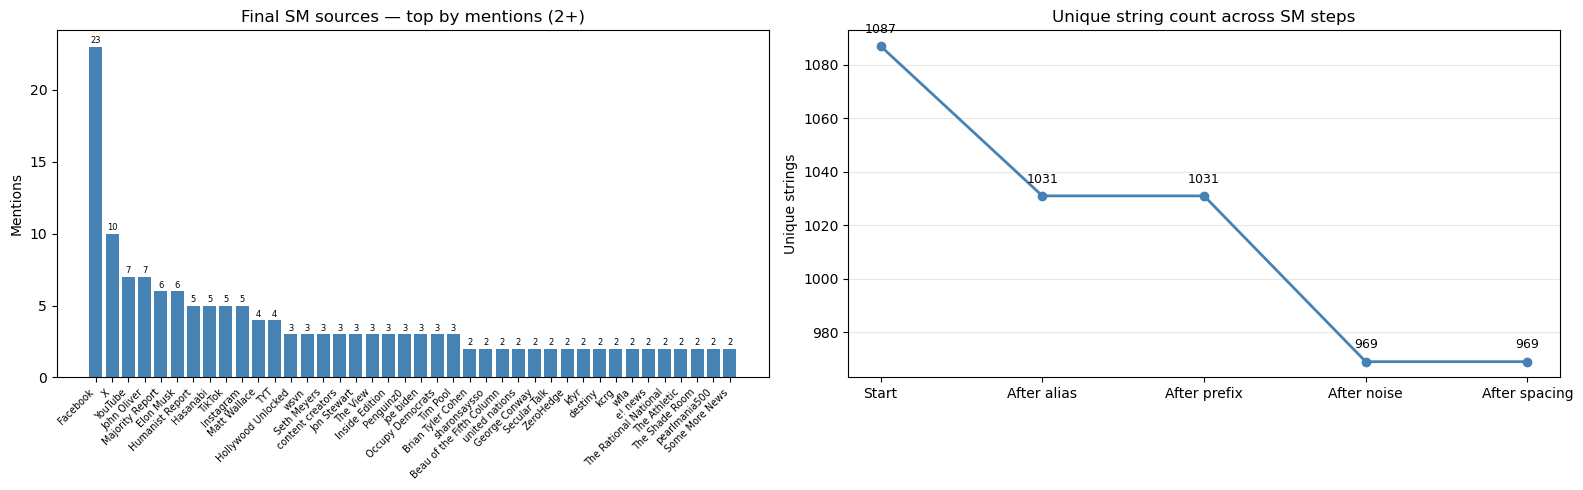

In [26]:
# Final chart — SM steps overview
steps   = ['Start', 'After alias', 'After prefix', 'After noise', 'After spacing']
uniques = [
    sm_only.nunique(),
    sm_step1.nunique(),
    sm_step2.nunique(),
    sm_step3[sm_step3 != 'NOISE'].nunique(),
    sm_final.nunique(),
]

freq_final_top = freq_sm_final[freq_sm_final['count'] >= 2].head(40)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(range(len(freq_final_top)), freq_final_top['count'], color='steelblue')
axes[0].set_xticks(range(len(freq_final_top)))
axes[0].set_xticklabels(freq_final_top['source'], rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Mentions')
axes[0].set_title('Final SM sources — top by mentions (2+)')
for bar, val in zip(bars, freq_final_top['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', va='bottom', fontsize=6)

axes[1].plot(steps, uniques, marker='o', color='steelblue', linewidth=2)
axes[1].set_ylabel('Unique strings')
axes[1].set_title('Unique string count across SM steps')
for i, (step, val) in enumerate(zip(steps, uniques)):
    axes[1].text(i, val + 5, str(val), ha='center', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sm_final.png', dpi=150)
plt.show()

## Proposals to improve MM and MM-in-SM sources

After analysing the SM pipeline, here are observations and proposed improvements for the MM and MM-in-SM sources.

**Observation 1: 'wallstreet journal' not caught by WSJ alias**
The MM ALIAS_MAP catches 'wall street journal' and 'wsj' but not 'wallstreet journal' (no space).
Proposal: add `r'\bwallstreet\s+journal\b'` → 'Wall Street Journal' to ALIAS_MAP.
Status: low priority (1–2 occurrences), but easy to add.

**Observation 2: 'facebook news' in SM columns appears as MM-in-SM**
'Facebook news' means the built-in Facebook news tab — this is SM, not MM-in-SM.
Proposal: add `r'\bfacebook\s+news\b'` → 'Facebook' to ALIAS_MAP before the generic 'facebook' entry.
Status: handled in SM_ALIAS_MAP above; if it appears in MM columns it needs adding to ALIAS_MAP too.

**Observation 3: Commentator names (Joe Biden, Elon Musk, Donald Trump) appear as sources**
In SM columns, people write politician names as their 'source' (they follow them directly).
These are not news sources — they should be labeled as 'SM-personality' rather than MM or NN.
Proposal: add a new category 'SM-personality' for known public figures appearing as SM sources.
Implementation: a short list of politician/celebrity names → label 'SM-personality' in the label() function.

**Observation 4: Local TV stations (WFLA, WSFA, KFYR, WSVN, KCRG) scattered across MM and SM**
These appear in both MM and SM columns, each with 2–3 mentions.
The current pipeline labels them MM (if in MM columns) but leaves them as-is without unifying.
Proposal: add a generic local-TV pattern `r'\b[WKN][A-Z]{2,4}\b'` → keep as-is but label 'Local TV'.
This avoids false merges while grouping them in analysis.

**Observation 5: 'cspan' not caught by ALIAS_MAP**
'cspan' should map to 'C-SPAN'. Currently handled in SM_ALIAS_MAP but not in the main ALIAS_MAP.
Proposal: add `r'\bc-?span\b'` → 'C-SPAN' to the main ALIAS_MAP. Implemented below.

In [27]:
# Proposed additions to the main ALIAS_MAP for MM sources
# Add these entries to the ALIAS_MAP in Step 6 for more complete MM unification

ALIAS_MAP_ADDITIONS = [
    # Wallstreet journal no-space variant
    (r'\bwallstreet\s+journal\b',        'Wall Street Journal'),

    # C-SPAN
    (r'\bc-?span\b',                     'C-SPAN'),

    # Facebook News tab — SM not MM
    (r'\bfacebook\s+news\b',             'Facebook'),

    # Local TV — keep name but could be used to label 'Local TV'
    # Pattern: call letters starting with W, K, or N followed by 2-4 uppercase letters
    # e.g. WFLA, WSFA, KFYR, WSVN, KCRG
    # Note: do NOT add to ALIAS_MAP directly — they stay as individual names.
    # Use in labelling step to assign category 'Local TV'.
]

print("Proposed ALIAS_MAP additions:")
for pat, name in ALIAS_MAP_ADDITIONS:
    print(f"  {pat!r:50s} → {name!r}")

print()
print("Local TV station pattern (for labelling, not merging):")
local_tv_pattern = r'\b[WKN][A-Z]{2,4}\b'
print(f"  {local_tv_pattern}")
print()
print("SM-personality candidates (people written as sources in SM columns):")
sm_personalities = ['joe biden', 'donald trump', 'elon musk', 'bernie sanders',
                    'kamala harris', 'ron desantis', 'barack obama']
for p in sm_personalities:
    count = sm_only[sm_only == p].count()
    if count > 0:
        print(f"  '{p}': {count} mentions")

Proposed ALIAS_MAP additions:
  '\\bwallstreet\\s+journal\\b'                      → 'Wall Street Journal'
  '\\bc-?span\\b'                                    → 'C-SPAN'
  '\\bfacebook\\s+news\\b'                           → 'Facebook'

Local TV station pattern (for labelling, not merging):
  \b[WKN][A-Z]{2,4}\b

SM-personality candidates (people written as sources in SM columns):
  'joe biden': 3 mentions
  'donald trump': 2 mentions
  'elon musk': 3 mentions
  'ron desantis': 1 mentions


# Step 6: Map all variants to one standard name
 

In [28]:
# Each entry: (regex pattern, standard name)
# \b = word boundary — \bcnn\b matches 'cnn' but not 'xcnn' or 'cnn2'
ALIAS_MAP = [
    # Exceptions first
    (r'\bfox\s*1[0-9]\b',                   'Fox 13'),           # local affiliates
    (r'\bgoogle\s+discover\b',               'Google Discover'),

    # New York Times
    (r'\bthe\s+new\s+york\s+times?\b',       'New York Times'),
    (r'\bnew\s+york\s+times?\b',             'New York Times'),
    (r'\bnytimes?\b',                        'New York Times'),
    (r'\bny\s+times?\b',                     'New York Times'),
    (r'\bnyt\b',                             'New York Times'),

    # CNN
    (r'\bcnn\s*news?\b',                     'CNN'),
    (r'\bcnn\b',                             'CNN'),

    # Sky News
    (r'\bsky\s*news\b',                      'Sky News'),
    (r'\bskynews\b',                         'Sky News'),

    # Fox News — fox13 already caught above
    # \bfox\b(?!\s*\d) = 'fox' not followed by a number
    (r'\bfox\s+news\b',                      'Fox News'),
    (r'\bfoxnews\b',                         'Fox News'),
    (r'\blivenow\s+from\s+fox\b',            'Fox News'),
    (r'\bfox\b(?!\s*\d)',                    'Fox News'),

    # BBC
    (r'\bbbcnews\b',                         'BBC News'),
    (r'\bbbc\s+world\s+news\b',              'BBC News'),
    (r'\bbbc\s+world\b',                     'BBC News'),
    (r'\bbbc(?:\s+news)?\b',                 'BBC News'),

    # Washington Post
    (r'\bthe\s+washington\s+post\b',         'Washington Post'),
    (r'\bwashington\s+post\b',               'Washington Post'),
    (r'\bwapo\b',                            'Washington Post'),
    (r'\bwashpost\b',                        'Washington Post'),
    (r'\bwashingtonpost\b',                  'Washington Post'),
    (r'\btwp\b',                             'Washington Post'),

    # MSNBC
    (r'\bmsnbc\b',                           'MSNBC'),

    # NBC
    (r'\bnbc\s+nightly\s+news\b',            'NBC News'),
    (r'\bnbc\s+washington\b',                'NBC News'),
    (r'\bnbc(?:\s+news)?\b',                 'NBC News'),

    # ABC
    (r'\babc\s+world\s+news\b',              'ABC News'),
    (r'\bgood\s+morning\s+america\b',        'ABC News'),
    (r'\babc\s*\d+\s*(?:news)?\b',           'ABC News'),  # abc7, abc7news
    (r'\babc(?:\s+news)?\b',                 'ABC News'),

    # CBS
    (r'\bcbs\s+evening\s+news\b',            'CBS News'),
    (r'\b60\s+minutes\b',                    'CBS News'),
    (r'\bcbs(?:\s+news)?\b',                 'CBS News'),

    # NPR — including 'npr (national public radio)' and 'national public radio'
    (r'\bnpr\b',                             'NPR'),
    (r'\bnational\s+public\s+radio\b',       'NPR'),

    # PBS
    (r'\bpbs(?:\s+news(?:hour)?)?\b',        'PBS NewsHour'),

    # Associated Press — bare 'ap' is 2 letters, small false-match risk but AP is frequent
    (r'\bassociated\s+press\b',              'Associated Press'),
    (r'\bapnews\b',                          'Associated Press'),
    (r'\bap\s+news\b',                       'Associated Press'),
    (r'\bap\b',                              'Associated Press'),

    # Reuters
    (r'\breuters\b',                         'Reuters'),

    # Wall Street Journal
    (r'\bthe\s+wall\s+street\s+journal\b',   'Wall Street Journal'),
    (r'\bwall\s+street\s+journal\b',         'Wall Street Journal'),
    (r'\bwsj\b',                             'Wall Street Journal'),

    # Al Jazeera — bare '\bal\b' NOT included (too many false matches: Alabama, etc.)
    (r'\bal\s+jazeera\b',                    'Al Jazeera'),
    (r'\baljazeera\b',                       'Al Jazeera'),

    # Yahoo News
    (r'\byahoo(?:\s+news)?\b',               'Yahoo News'),

    # Google News (Discover already caught above)
    (r'\bgoogle(?:\s+news)?\b',              'Google News'),

    # Atlanta Journal-Constitution
    (r'\batlanta\s+journal[\s\-]+constitution\b', 'Atlanta Journal-Constitution'),
    (r'\batlanta\s+journal\b',               'Atlanta Journal-Constitution'),
    (r'\bajc\b',                             'Atlanta Journal-Constitution'),

    # Social media
    (r'\bfacebook\b',                        'Facebook'),
    (r'\bfb\b',                              'Facebook'),
    (r'\binstagram\b',                       'Instagram'),
    (r'\big\b(?!n)',                         'Instagram'),   # 'ig' but not 'ign'
    (r'\btiktok\b',                          'TikTok'),
    (r'\btwitter\b',                         'Twitter/X'),
    (r'\bx\.com\b',                          'Twitter/X'),
    (r'\byoutube\b',                         'YouTube'),
    (r'\byt\b',                              'YouTube'),
    (r'\breddit\b',                          'Reddit'),
    (r'\bsnapchat\b',                        'Snapchat'),
    (r'\bdiscord\b',                         'Discord'),
    (r'\bpinterest\b',                       'Pinterest'),
    (r'\blinkedin\b',                        'LinkedIn'),
    (r'\bthreads\b',                         'Threads'),
    (r'\bbluesky\b',                         'Bluesky'),
    (r'\bmastodon\b',                        'Mastodon'),
    (r'\btwitch\b',                          'Twitch'),

    # Other outlets
    (r'\busa\s+today\b',                     'USA Today'),
    (r'\bla\s+times\b',                      'Los Angeles Times'),
    (r'\blos\s+angeles\s+times\b',           'Los Angeles Times'),
    (r'\blatimes\b',                         'Los Angeles Times'),
    (r'\bboston\s+globe\b',                  'Boston Globe'),
    (r'\bnewsweek\b',                        'Newsweek'),
    (r'\btime(?:\s+magazine)?\b',            'TIME Magazine'),
    (r'\bpolitico\b',                        'Politico'),
    (r'\bbloomberg\b',                       'Bloomberg'),
    (r'\bcnbc\b',                            'CNBC'),
    (r'\bforbes\b',                          'Forbes'),
    (r'\beconomist\b',                       'The Economist'),
    (r'\bfinancial\s+times\b',               'Financial Times'),
    (r'\bft\b',                              'Financial Times'),
    (r'\bvox\b',                             'Vox'),
    (r'\bthe\s+atlantic\b',                  'The Atlantic'),
    (r'\batlantic\b',                        'The Atlantic'),
    (r'\bnew\s+yorker\b',                    'The New Yorker'),
    (r'\bguardian\b',                        'The Guardian'),
    (r'\btheguardian\b',                     'The Guardian'),
    (r'\baxios\b',                           'Axios'),
    (r'\bthe\s+hill\b',                      'The Hill'),
    (r'\bhuffpost\b',                        'HuffPost'),
    (r'\bhuffington\s+post\b',               'HuffPost'),
    (r'\bbuzzfeed\b',                        'BuzzFeed'),
    (r'\bespn\b',                            'ESPN'),
    (r'\bbreitbart\b',                       'Breitbart'),
    (r'\bdaily\s+wire\b',                    'Daily Wire'),
    (r'\bthe\s+daily\s+wire\b',              'Daily Wire'),
    (r'\bthe\s+blaze\b',                     'The Blaze'),
    (r'\bdaily\s+mail\b',                    'Daily Mail'),
    (r'\bnypost\b',                          'New York Post'),
    (r'\bnew\s+york\s+post\b',               'New York Post'),
    (r'\bny\s+post\b',                       'New York Post'),
    (r'\bmsn\b',                             'MSN News'),
    (r'\bapple\s+news\b',                    'Apple News'),
    (r'\bflipboard\b',                       'Flipboard'),
    (r'\bground\.news\b',                    'Ground News'),
    (r'\bground\s+news\b',                   'Ground News'),
    (r'\bnewsmax\b',                         'Newsmax'),
    (r'\bnewsnation\b',                      'NewsNation'),
    (r'\bdw\b',                              'DW (Deutsche Welle)'),
    (r'\bdeutsche\s+welle\b',                'DW (Deutsche Welle)'),
    (r'\bpropublica\b',                      'ProPublica'),
    (r'\btmz\b',                             'TMZ'),
    (r'\bslate\b',                           'Slate'),
    (r'\bvice\b',                            'Vice'),
    (r'\bsalon\b',                           'Salon'),
    (r'\bzerohedge\b',                       'ZeroHedge'),
    (r'\bmarketwatch\b',                     'MarketWatch'),
    (r'\btelemundo\b',                       'Telemundo'),
    (r'\bunivision\b',                       'Univision'),
    (r'\bcbc\b',                             'CBC'),
    (r'\bdrudge\s*report\b',                 'Drudge Report'),
    (r'\breal\s+clear\s+politics\b',         'RealClearPolitics'),
    (r'\bthe\s+daily\s+show\b',              'The Daily Show'),
    (r'\bdaily\s+show\b',                    'The Daily Show'),
    (r'\bbreaking\s+points\b',               'Breaking Points'),
    (r'\bdemocracy\s+now\b',                 'Democracy Now'),
    (r'\bpod\s+save\s+america\b',            'Pod Save America'),
    (r'\bmeidas\s*touch\b',                  'MeidasTouch'),
    (r'\bthe\s+young\s+turks\b',             'TYT'),
    (r'\btyt\b',                             'TYT'),
    (r'\bgreenbrier\s+news\b',               'Greenbrier News'),
    (r'\bnews\s*break\b',                    'NewsBreak'),
    (r'\bpolitifact\b',                      'PolitiFact'),
    (r'\bsnopes\b',                          'Snopes'),
    (r'\b1440\b',                            '1440 Daily Digest'),
    (r'\bunder\s*the\s*desk\s*news\b',       'Under the Desk News'),
    (r'\bunderthedesknews\b',                'Under the Desk News'),
]

def unify(s):
    for pattern, standard_name in ALIAS_MAP:
        if re.search(pattern, s):
            return standard_name
    return s.title()

unified_series = all_extracted_step4.apply(unify)

# Frequency table after unification
unified_freq = unified_series.value_counts().reset_index()
unified_freq.columns = ['source', 'count']

unique_pre  = all_extracted_step4.nunique()
unique_post = unified_series.nunique()
print(f"Unique strings before step 6: {unique_pre}")
print(f"Unique strings after  step 6: {unique_post}")
print(f"Reduced by: {unique_pre - unique_post} ({(unique_pre-unique_post)/unique_pre*100:.1f}%)")
print()
top_unified = unified_freq[unified_freq['count'] >= 4].copy()
print(f"Sources with 4+ mentions: {len(top_unified)}")
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_unified.to_string())

Unique strings before step 6: 2095
Unique strings after  step 6: 1973
Reduced by: 122 (5.8%)

Sources with 4+ mentions: 123
                           source  count
0                             CNN    664
1                        Fox News    532
2                  New York Times    346
3                        ABC News    303
4                           Times    302
5                        NBC News    282
6                        BBC News    259
7                             NPR    203
8                           MSNBC    200
9                        CBS News    184
10                Washington Post    141
11                    Google News    134
12                     Local News    105
13            Wall Street Journal     88
14                     Yahoo News     84
15               Associated Press     83
16                   The Guardian     78
17                          Today     67
18                        Reuters     65
19                           CNBC     48
20             

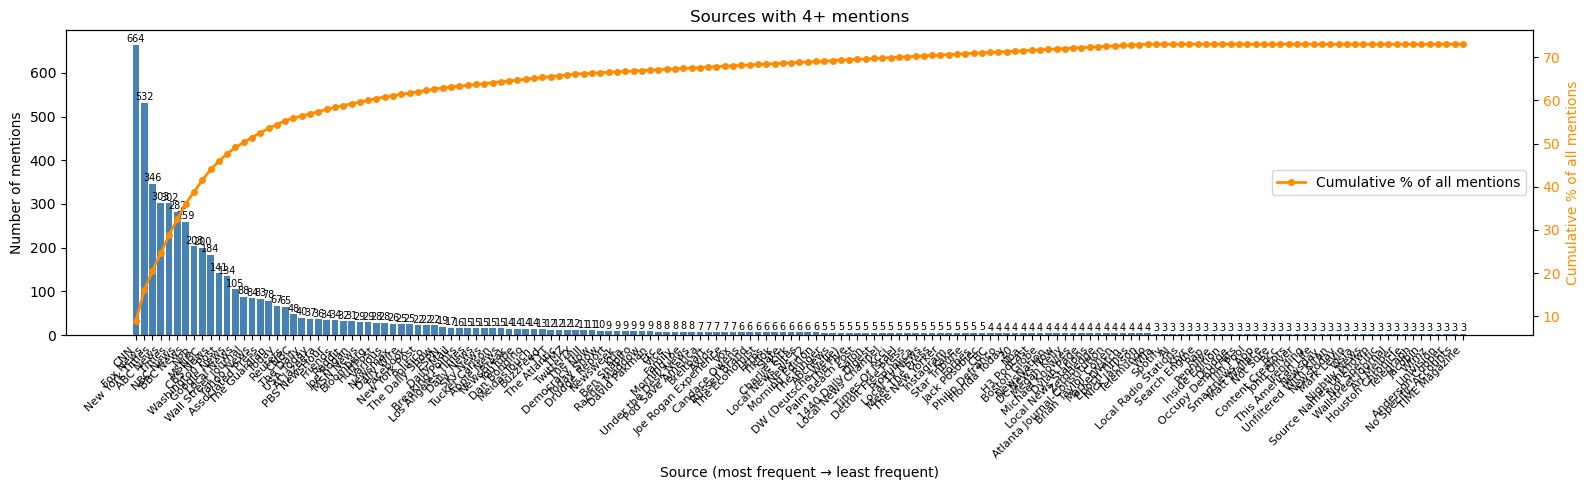

Total mentions in dataset: 7450

  Top  1 sources cover 664 of 7450 mentions (8.9%)
  Top  5 sources cover 2147 of 7450 mentions (28.8%)
  Top 10 sources cover 3275 of 7450 mentions (44.0%)
  Top 20 sources cover 4168 of 7450 mentions (55.9%)
  Top 40 sources cover 4720 of 7450 mentions (63.4%)
  Top 80 sources cover 5115 of 7450 mentions (68.7%)
  Top 161 sources cover 5427 of 7450 mentions (72.8%)


In [29]:
# Bar chart: top 40 sources on x axis, number of mentions on y axis
# Cumulative line shows how many total mentions are covered by the top N sources

total_mentions = unified_freq['count'].sum()
top40 = unified_freq.head(161).copy()
top40['pct'] = (top40['count'] / total_mentions * 100).round(1)
top40['cumulative_pct'] = top40['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top40['source'], top40['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Sources with 4+ mentions')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top40['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

# Cumulative count line — shows how many total mentions are covered as you add more sources
ax2 = ax.twinx()
ax2.plot(top40['source'], top40['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step3.png', dpi=150)
plt.show()

print(f"Total mentions in dataset: {total_mentions}")
print()
for n in [1, 5, 10, 20, 40, 80, 161]:
    covered = top40.head(n)['count'].sum()
    print(f"  Top {n:2d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")